In [2]:
import sys
sys.path.append("../..")
from src.sawmill.sawmill import Sawmill
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

In [3]:
s = Sawmill(
    filename="~/causal-log/datasets_raw/xyz_extended/log_2024-01-08_20:09:23.log",
    workdir="../../datasets/xyz_extended/",
)
s.parse(
    regex_dict={
        "timestamp": r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{6}Z",
        "machine": r"machine_\d+",
    }
)

Initialized Sawmill with log file ~/causal-log/datasets_raw/xyz_extended/log_2024-01-08_20:09:23.log
Work directory set to ../../datasets/xyz_extended/


Loading existing pkl file ../../datasets/xyz_extended/log_2024-01-08_20:09:23.log_parsed_log_None_None.pkl...:…

Loading existing pkl file ../../datasets/xyz_extended/log_2024-01-08_20:09:23.log_parsed_templates_None_None.p…

Loading existing pkl file ../../datasets/xyz_extended/log_2024-01-08_20:09:23.log_parsed_variables_None_None.p…

Parsing complete in 0.241678 seconds!


'0.241678'

In [4]:
s.set_causal_unit('machine')
s.prepare(count_occurences=True, reject_prunable_edges=False)

Causal unit set to machine (tag: machine) 


Loading existing pkl file ../../datasets/xyz_extended/log_2024-01-08_20:09:23.log_prepared_log_machine_None.pk…

Loading existing pkl file ../../datasets/xyz_extended/log_2024-01-08_20:09:23.log_prepared_variables_machine_N…

Preparation complete in 0.083725 seconds! 21 of the 441 possible edges were auto-rejected.


'0.083725'

In [6]:
s.inspect('x mean')

Information about prepared variable d1a33a13_4+mean:

--> Variable Information about d1a33a13_4:


,Name,Tag,Type,IsUninteresting,Occurrences,Preceding 3 tokens,Examples,From regex
9,d1a33a13_4,x,num,False,100104,"[<*1>, x, =]","[7.8459842601241, 6.675556699713145, 6.197634404131371, 6.8441254671857275, 7.985363085803397]",False


--> Template Information about d1a33a13:


,TemplateText,TemplateId,VariableIndices,RegexIndices,TemplateExample,Occurrences
7,<*0> <*1> x = <*>,d1a33a13,[4],"[0, 1]",<*0> <*1> x = 7.8459842601241,100104


--> Causal Unit Partial Information:


,d1a33a13_4+mean (candidate)
machine+last,
machine_0,7.562377
machine_1,5.580641
machine_10,0.916133
machine_100,6.055724
machine_101,9.896941
machine_102,5.900430
machine_103,1.421646
machine_104,5.504388
machine_105,3.145578


In [7]:
s.inspect('y mean')

Information about prepared variable caa5dc5d_4+mean:

--> Variable Information about caa5dc5d_4:


,Name,Tag,Type,IsUninteresting,Occurrences,Preceding 3 tokens,Examples,From regex
10,caa5dc5d_4,y,num,False,100514,"[<*1>, y, =]","[41.493943248271606, 37.835604055769025, 42.413488599242086, 37.19854020775029, 38.17732345483762]",False


--> Template Information about caa5dc5d:


,TemplateText,TemplateId,VariableIndices,RegexIndices,TemplateExample,Occurrences
8,<*0> <*1> y = <*>,caa5dc5d,[4],"[0, 1]",<*0> <*1> y = 41.493943248271606,100514


--> Causal Unit Partial Information:


,caa5dc5d_4+mean (candidate)
machine+last,
machine_0,38.638962
machine_1,27.908158
machine_10,3.712983
machine_100,30.324384
machine_101,48.981451
machine_102,29.284067
machine_103,5.891084
machine_104,27.477157
machine_105,17.161109


In [8]:
(s.prepared_log['caa5dc5d_4+mean'] / s.prepared_log['d1a33a13_4+mean']).mean()


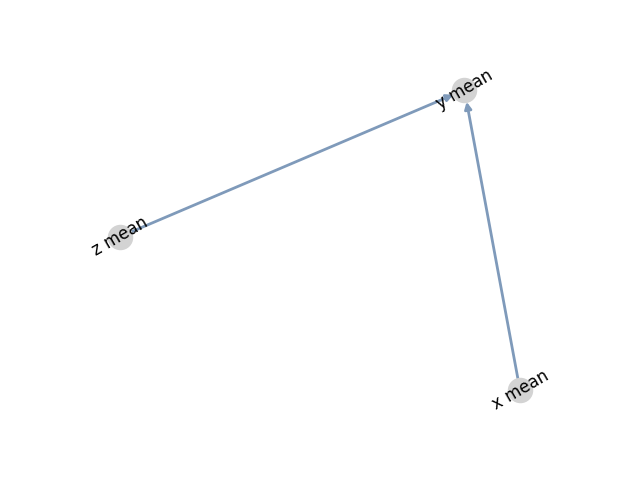

(0.03508771929824561, 'd1a33a13_4+mean', '')

In [9]:
s.accept('x mean', 'y mean', interactive=False)
s.accept('z mean', 'y mean')

In [11]:
s.get_unadjusted_ate('x mean', 'y mean')

In [12]:
s.explore_candidate_causes('x mean')

Candidate cause exploration complete in 1.089643 seconds!


(         Candidate Candidate Tag           Target     Slope  P-value Candidate->Target Edge Status Target->Candidate Edge Status
 0  caa5dc5d_4+mean        y mean  d1a33a13_4+mean  0.197442      0.0                      Rejected                      Accepted
 1  de74037b_4+mean        z mean  d1a33a13_4+mean  0.985033      0.0                     Undecided                     Undecided,
 '1.089643')


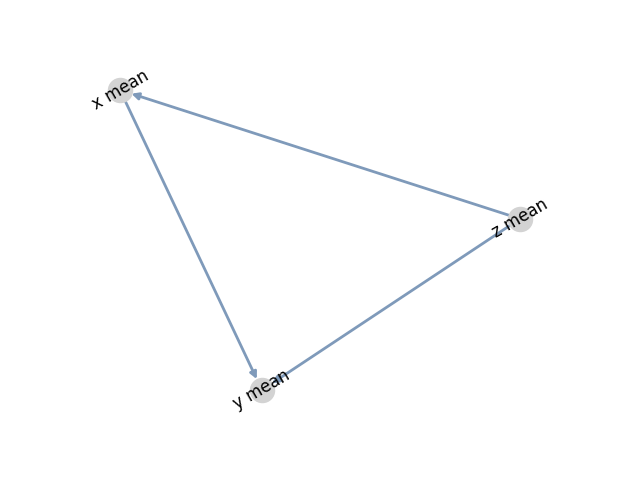

(0.21052631578947367, 'caa5dc5d_4+mean', '')

In [13]:
s.accept('z mean', 'x mean')

In [15]:
s.get_adjusted_ate('x mean', 'y mean')

In [14]:
s.get_unadjusted_ate('x mean', 'y mean')

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Number of machines (data points)
n = 100
s = 100

# Generating data
z = np.random.uniform(0, 100, n)  # Fixed value of z for each machine
x = []
y = []

for i in range(n):
    # Create 100 random values of x for each machine, each given by z + np.random.normal(0, 1, n) 
    x_samples = [z[i]]*s + np.random.normal(0, 1, s)

    # Generating y based on the true relationship
    y_samples = 2 * x_samples + ([3 *z[i]]*s) + np.random.normal(0, 1, s)

    x.append(x_samples.mean())
    y.append(y_samples.mean())

# Dataframe for regression analysis
data = pd.DataFrame({'x': x, 'y': y, 'z': z})

# Simple regression (without z) to calculate initial ATE
model_simple = sm.OLS(data['y'], sm.add_constant(data['x'])).fit()

# Multiple regression (with z) to calculate adjusted ATE
model_adjusted = sm.OLS(data['y'], sm.add_constant(data[['x', 'z']])).fit()

# Coefficients (ATE) from both models
ate_initial = model_simple.params['x']
ate_adjusted = model_adjusted.params['x']

ate_initial, ate_adjusted

In [1]:
import pandas as pd

df = pd.read_csv('~/causal-log/evaluation/xyz_extended/xyz_extended_resultslog_2024-01-08 20:44:48.012925.txt')

In [3]:
df['total_time'] = df['parse_time'] + df['prep_time'] + df['model_time']
df['total_time'].mean()

483.9433333333334

In [4]:
df['error_pct'].mean()

57.64444444444444